In [1]:
# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
# ------------------------------------------------------------
# 2. LOAD FOODHUB DATASET
# ------------------------------------------------------------

df = pd.read_csv("foodhub_order-Copy1.csv")
print("First 5 Records:")
print(df.head())
print("\nDataset Information:")
df.info()
print("\nDataset Shape:")
print(df.shape)

First 5 Records:
   order_id  customer_id            restaurant_name cuisine_type  \
0   1477147       337525                    Hangawi       Korean   
1   1477685       358141  Blue Ribbon Sushi Izakaya     Japanese   
2   1477070        66393                Cafe Habana      Mexican   
3   1477334       106968  Blue Ribbon Fried Chicken     American   
4   1478249        76942           Dirty Bird to Go     American   

   cost_of_the_order day_of_the_week     rating  food_preparation_time  \
0              30.75         Weekend  Not given                     25   
1              12.08         Weekend  Not given                     25   
2              12.23         Weekday          5                     23   
3              29.20         Weekend          3                     25   
4              11.59         Weekday          4                     25   

   delivery_time  
0             20  
1             23  
2             28  
3             15  
4             24  

Dataset Inform

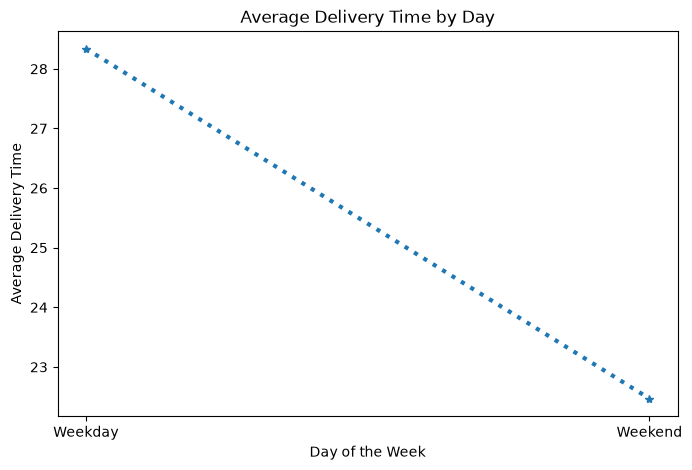

In [3]:
# ------------------------------------------------------------
# 3. LINE PLOT
# ------------------------------------------------------------

# Calculate average delivery time for each day

day_delivery = df.groupby("day_of_the_week")["delivery_time"].mean()

plt.figure(figsize=(8,5))

plt.plot(day_delivery.index,
         day_delivery.values,
         marker='*',
         linestyle='dotted',
         linewidth=3)

plt.xlabel("Day of the Week")
plt.ylabel("Average Delivery Time")
plt.title("Average Delivery Time by Day")

plt.show()

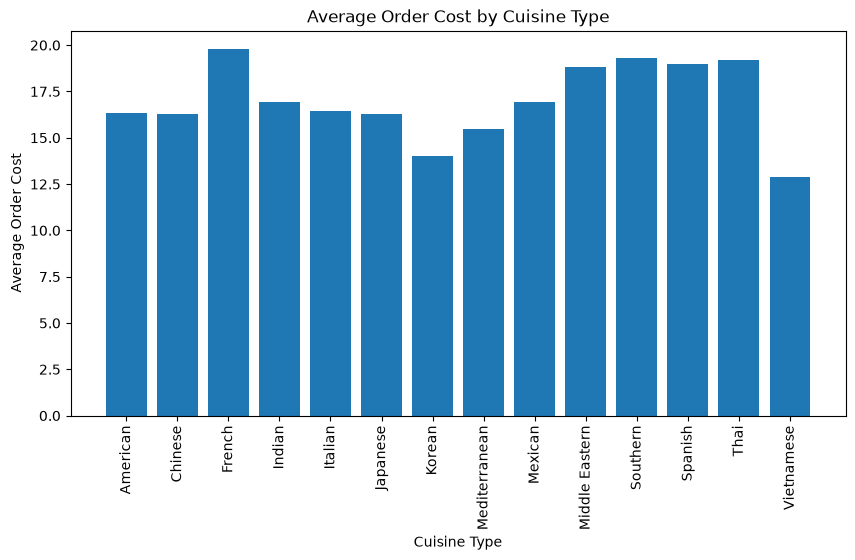

<Figure size 640x480 with 0 Axes>

In [4]:
# ------------------------------------------------------------
# 4. BAR CHART
# ------------------------------------------------------------

cuisine_cost = df.groupby("cuisine_type")["cost_of_the_order"].mean()
plt.figure(figsize=(10,5))

plt.bar(cuisine_cost.index,
        cuisine_cost.values)

plt.xlabel("Cuisine Type")
plt.ylabel("Average Order Cost")
plt.title("Average Order Cost by Cuisine Type")

plt.xticks(rotation=90)

plt.show()
plt.savefig("Average Order Cost by Cuisine Type.png")

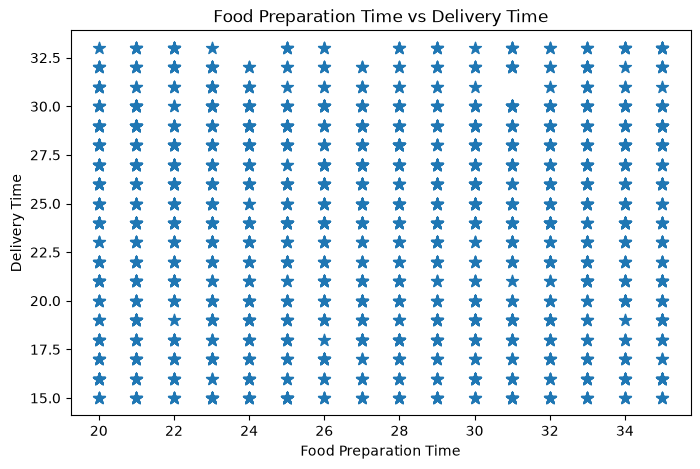

<Figure size 640x480 with 0 Axes>

In [5]:
# ------------------------------------------------------------
# 5. SCATTER PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(df["food_preparation_time"],
            df["delivery_time"],
            marker='*',
            s=80)

plt.xlabel("Food Preparation Time")
plt.ylabel("Delivery Time")
plt.title("Food Preparation Time vs Delivery Time")

plt.show()
plt.savefig("Food Preparation Time vs Delivery Time.png")


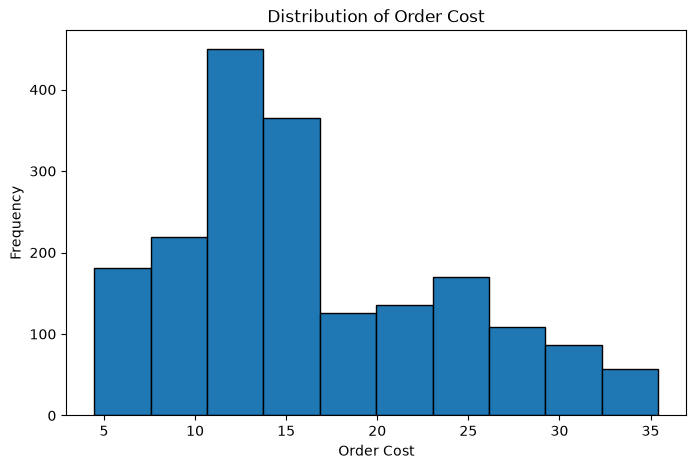

<Figure size 640x480 with 0 Axes>

In [6]:
# ------------------------------------------------------------
# 6. HISTOGRAM
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(df["cost_of_the_order"],
         bins=10,
         edgecolor="black")

plt.xlabel("Order Cost")
plt.ylabel("Frequency")
plt.title("Distribution of Order Cost")

plt.show()
plt.savefig("Distribution of Order Cost.png")


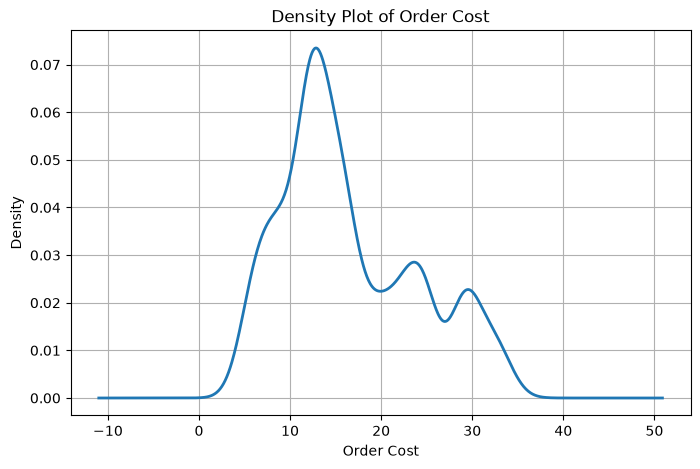

<Figure size 640x480 with 0 Axes>

In [7]:
# ------------------------------------------------------------
# 7. DENSITY PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

df["cost_of_the_order"].plot(
    kind="density",
    linewidth=2
)

plt.xlabel("Order Cost")
plt.title("Density Plot of Order Cost")

plt.grid()
plt.show()
plt.savefig("Density Plot of Order Cost.png")

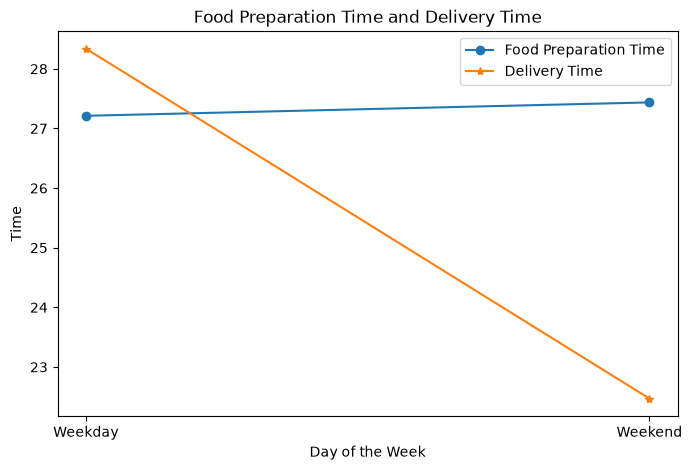

<Figure size 640x480 with 0 Axes>

In [8]:
# ------------------------------------------------------------
# 8. MULTIPLE LINE PLOT
# ------------------------------------------------------------

day_stats = df.groupby("day_of_the_week").agg({
    "food_preparation_time": "mean",
    "delivery_time": "mean"
})

plt.figure(figsize=(8,5))

plt.plot(day_stats.index,
         day_stats["food_preparation_time"],
         marker='o',
         label="Food Preparation Time")

plt.plot(day_stats.index,
         day_stats["delivery_time"],
         marker='*',
         label="Delivery Time")

plt.xlabel("Day of the Week")
plt.ylabel("Time")
plt.title("Food Preparation Time and Delivery Time")

plt.legend()
plt.show()
plt.savefig("Food Preparation Time and Delivery Time.png")

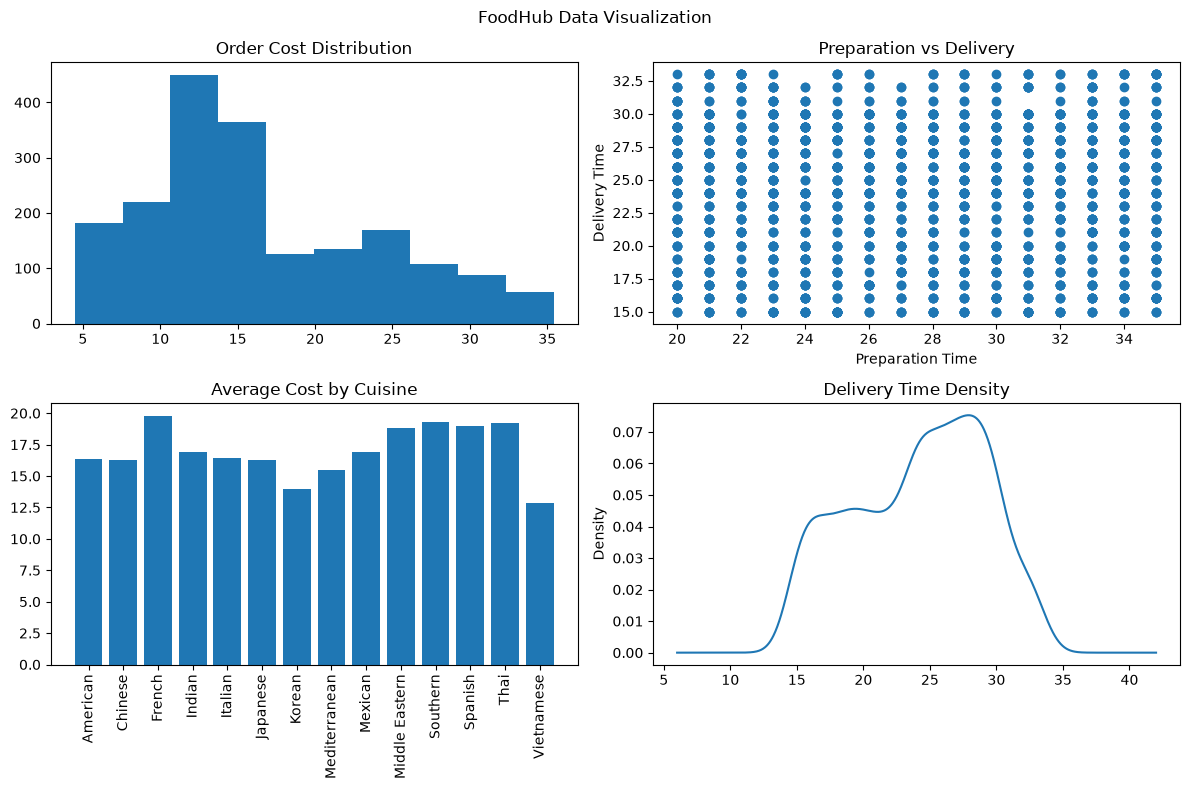

<Figure size 640x480 with 0 Axes>

In [9]:
# ------------------------------------------------------------
# 9. SUBPLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)

plt.hist(df["cost_of_the_order"],
         bins=10)

plt.title("Order Cost Distribution")


plt.subplot(2,2,2)

plt.scatter(df["food_preparation_time"],
            df["delivery_time"])

plt.xlabel("Preparation Time")
plt.ylabel("Delivery Time")
plt.title("Preparation vs Delivery")


plt.subplot(2,2,3)

plt.bar(cuisine_cost.index,
        cuisine_cost.values)

plt.xticks(rotation=90)
plt.title("Average Cost by Cuisine")


plt.subplot(2,2,4)

df["delivery_time"].plot(kind="density")

plt.title("Delivery Time Density")


plt.suptitle("FoodHub Data Visualization")

plt.tight_layout()
plt.show()
plt.savefig("FoodHub Data Visualization.png")

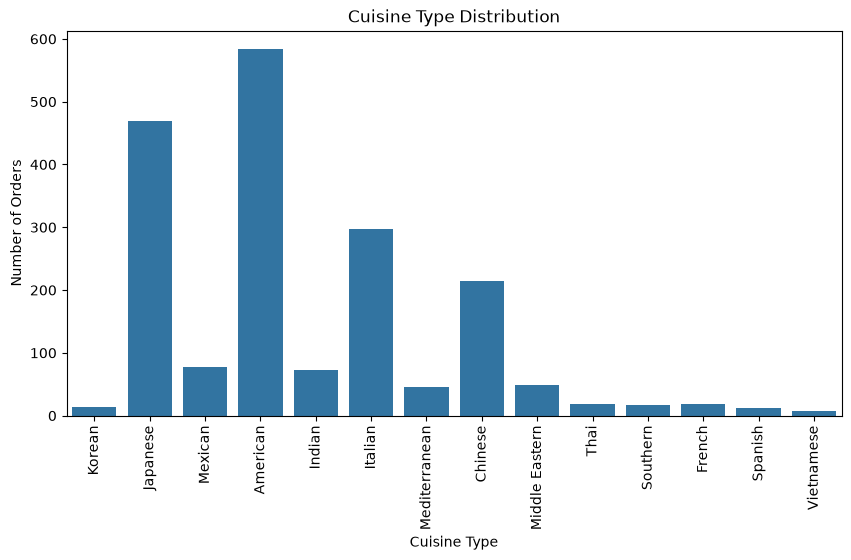

<Figure size 640x480 with 0 Axes>

In [10]:
# ------------------------------------------------------------
# 10. COUNT PLOT - CUISINE TYPE
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="cuisine_type")

plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.title("Cuisine Type Distribution")

plt.xticks(rotation=90)

plt.show()
plt.savefig("Cuisine Type Distribution.png")

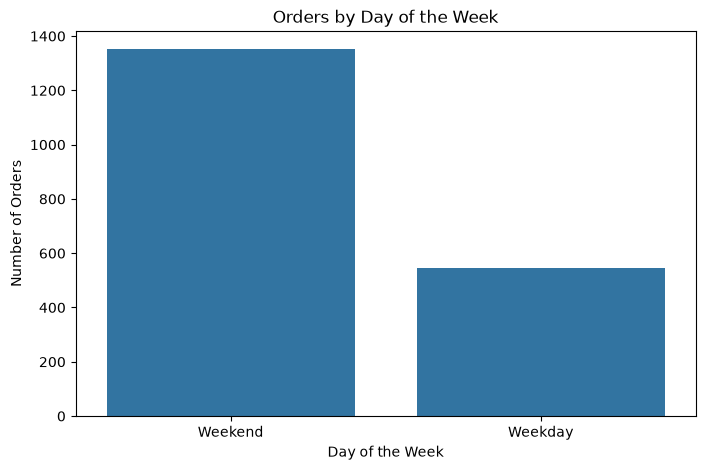

<Figure size 640x480 with 0 Axes>

In [11]:
# ------------------------------------------------------------
# 11. COUNT PLOT - DAY OF WEEK
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="day_of_the_week")

plt.xlabel("Day of the Week")
plt.ylabel("Number of Orders")
plt.title("Orders by Day of the Week")

plt.show()
plt.savefig("Orders by Day of the Week.png")

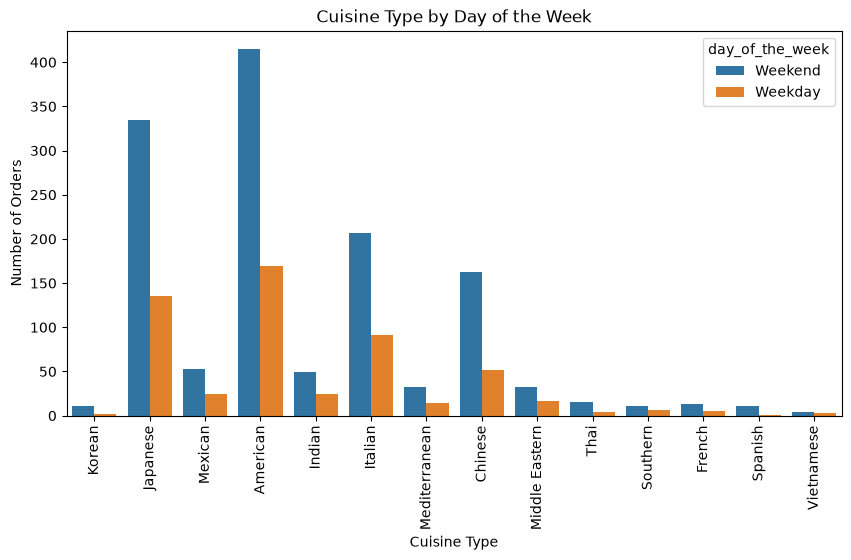

<Figure size 640x480 with 0 Axes>

In [12]:
# ------------------------------------------------------------
# 12. COUNT PLOT WITH HUE
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="cuisine_type",
              hue="day_of_the_week")

plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.title("Cuisine Type by Day of the Week")

plt.xticks(rotation=90)

plt.show()
plt.savefig("Cuisine Type by Day of the Week.png")

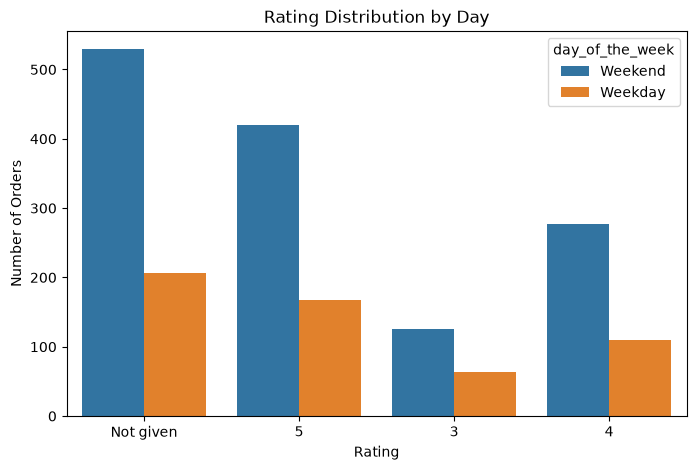

<Figure size 640x480 with 0 Axes>

In [13]:
# ------------------------------------------------------------
# 13. RATING BY DAY
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="rating",
              hue="day_of_the_week")

plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.title("Rating Distribution by Day")

plt.show()
plt.savefig("Rating Distribution by Day.png")

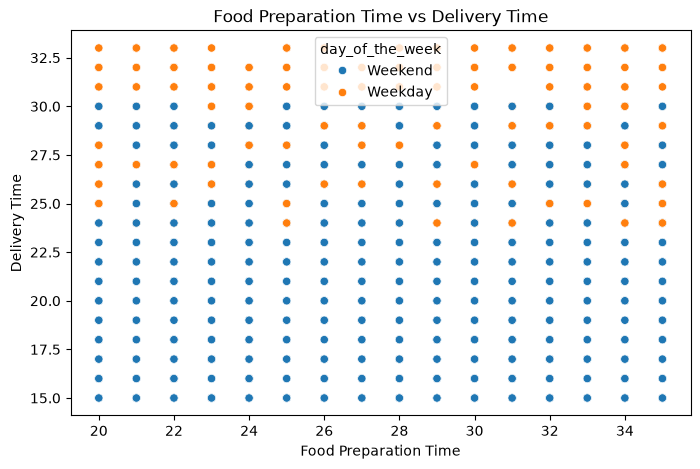

<Figure size 640x480 with 0 Axes>

In [14]:
# ------------------------------------------------------------
# 14. SCATTER PLOT USING SEABORN
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="food_preparation_time",
                y="delivery_time",
                hue="day_of_the_week")

plt.xlabel("Food Preparation Time")
plt.ylabel("Delivery Time")
plt.title("Food Preparation Time vs Delivery Time")

plt.show()
plt.savefig("Food Preparation Time vs Delivery Time.png")

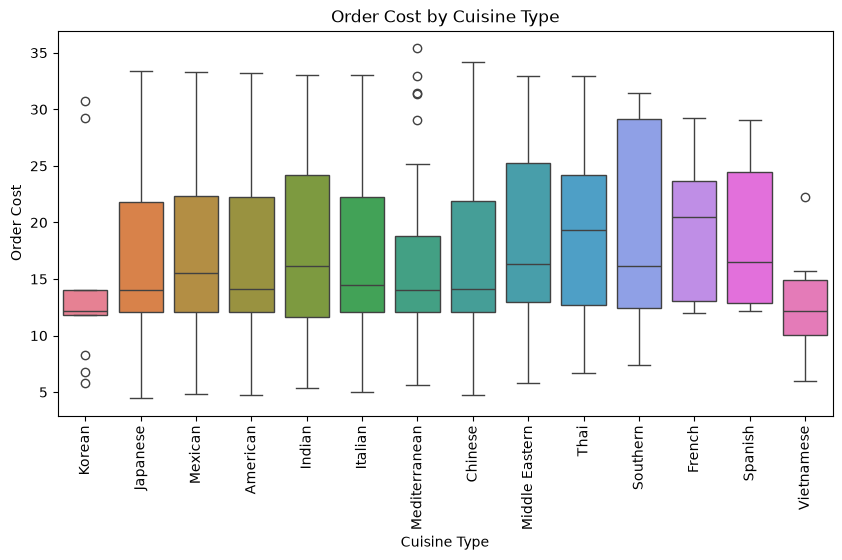

<Figure size 640x480 with 0 Axes>

In [15]:
# ------------------------------------------------------------
# 15. BOX PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.boxplot(data=df,
            x="cuisine_type",
            y="cost_of_the_order",
            hue="cuisine_type",
            legend=False)

plt.xlabel("Cuisine Type")
plt.ylabel("Order Cost")
plt.title("Order Cost by Cuisine Type")

plt.xticks(rotation=90)

plt.show()
plt.savefig("Order Cost by Cuisine Type.png")

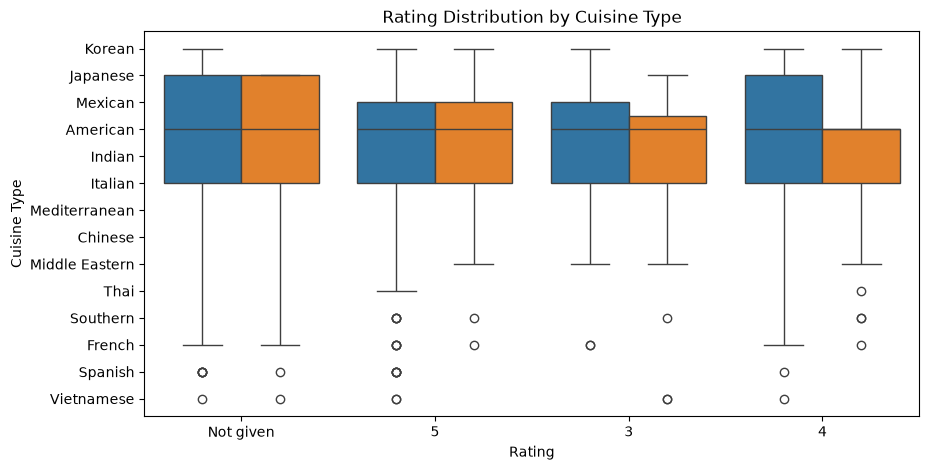

<Figure size 640x480 with 0 Axes>

In [16]:
# ------------------------------------------------------------
# 16. BOX PLOT - RATING AND CUISINE TYPE
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.boxplot(data=df,
            x="rating",
            y="cuisine_type",
            hue="day_of_the_week",
            legend=False)

plt.xlabel("Rating")
plt.ylabel("Cuisine Type")
plt.title("Rating Distribution by Cuisine Type")

plt.show()

plt.savefig("Rating Distribution by Cuisine Type.png")


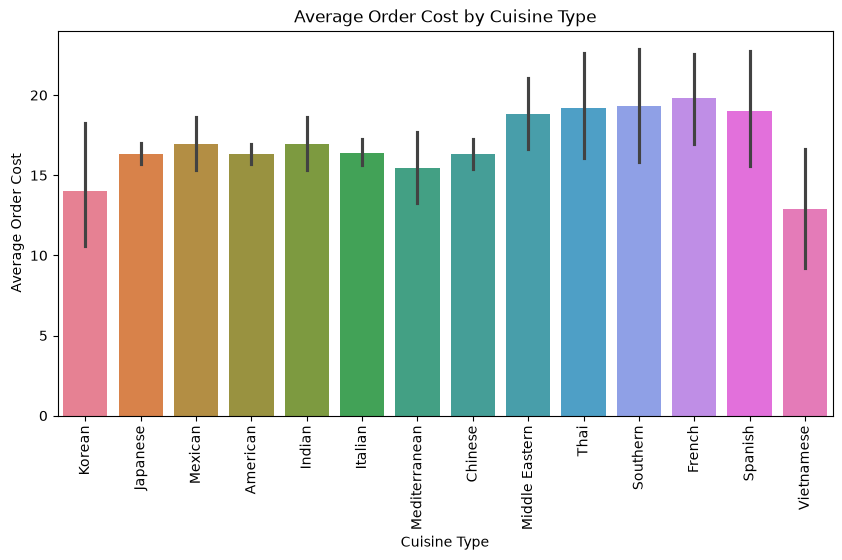

<Figure size 640x480 with 0 Axes>

In [17]:
# ------------------------------------------------------------
# 17. BAR PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.barplot(data=df,
            x="cuisine_type",
            y="cost_of_the_order",
            hue="cuisine_type")

plt.xlabel("Cuisine Type")
plt.ylabel("Average Order Cost")
plt.title("Average Order Cost by Cuisine Type")

plt.xticks(rotation=90)

plt.show()
plt.savefig("Average Order Cost by Cuisine Type.png")

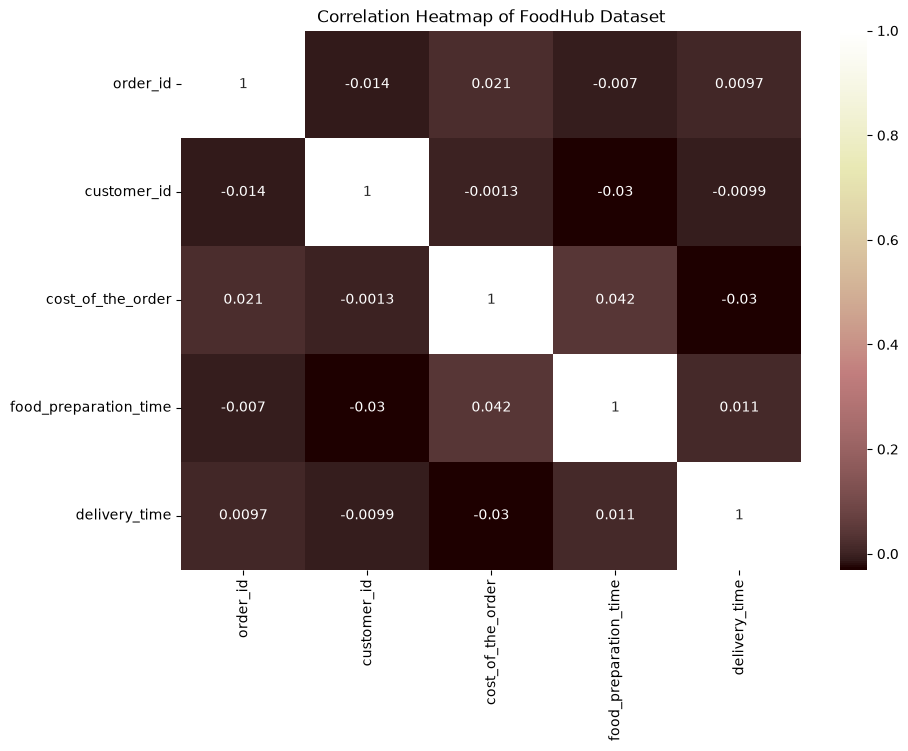

<Figure size 640x480 with 0 Axes>

In [18]:
# ------------------------------------------------------------
# 18. CORRELATION HEATMAP
# ------------------------------------------------------------

df1 = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,7))

sns.heatmap(df1.corr(),
            annot=True,
            cmap="pink")

plt.title("Correlation Heatmap of FoodHub Dataset")

plt.show()
plt.savefig("Correlation Heatmap of FoodHub Dataset.png")

# ============================================================
# END OF PROGRAM
# ============================================

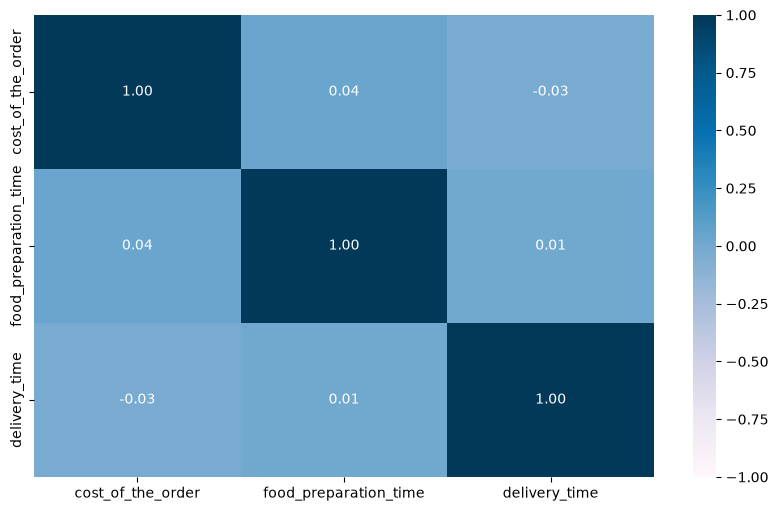

In [19]:
# Plot the heatmap
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(10, 6))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap='PuBu')
plt.show()

C:\Users\Janani\AppData\Local\Temp\ipykernel_9720\1325370540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='cost_of_the_order', data=df, palette='Set2')


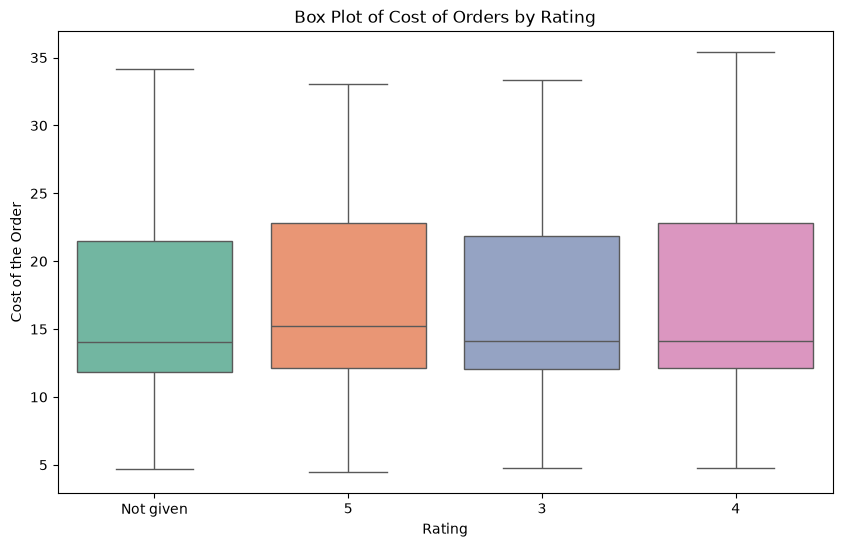

In [20]:
# Create a figure with the specified figure size
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize the relationship between rating and cost of orders
sns.boxplot(x='rating', y='cost_of_the_order', data=df, palette='Set2')

# Customize plot labels and title for better readability
plt.xlabel('Rating')  # X-axis label
plt.ylabel('Cost of the Order')  # Y-axis label
plt.title('Box Plot of Cost of Orders by Rating')  # Plot title

# Show the plot
plt.show()

C:\Users\Janani\AppData\Local\Temp\ipykernel_9720\1769059275.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "cuisine_type", y = "food_preparation_time", data = df, palette = 'RdBu_r')


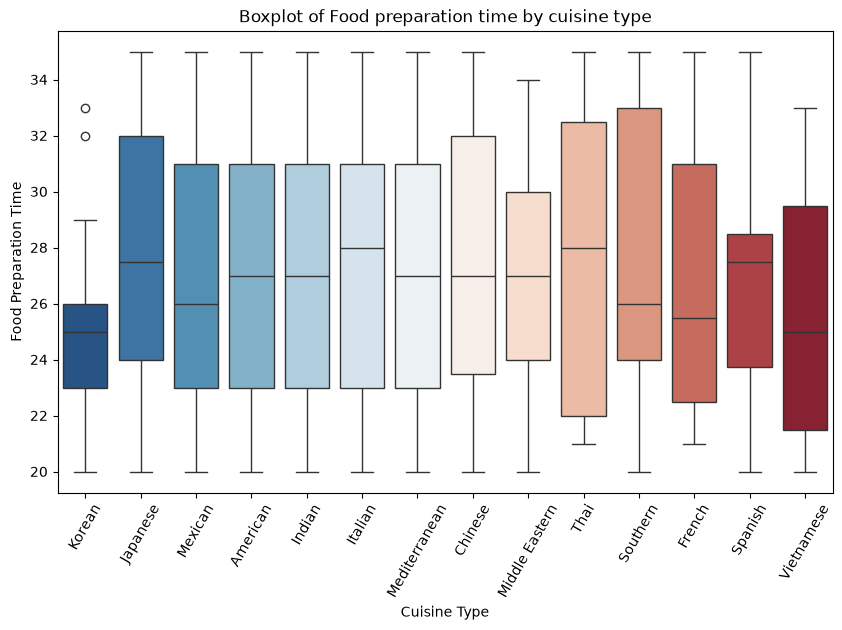

In [23]:
# Relationship between food preparation time and cuisine type
plt.figure(figsize=(10,6))

#Creating Boxplot with food preparation time by cuisine time
sns.boxplot(x = "cuisine_type", y = "food_preparation_time", data = df, palette = 'RdBu_r')

# Set labels and title
plt.xticks(rotation = 60)
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time')
plt.title('Boxplot of Food preparation time by cuisine type')
plt.show()


C:\Users\Janani\AppData\Local\Temp\ipykernel_9720\2444878526.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_weekend, x='cuisine_type', palette = 'cubehelix')  # Creating a countplot using Seaborn


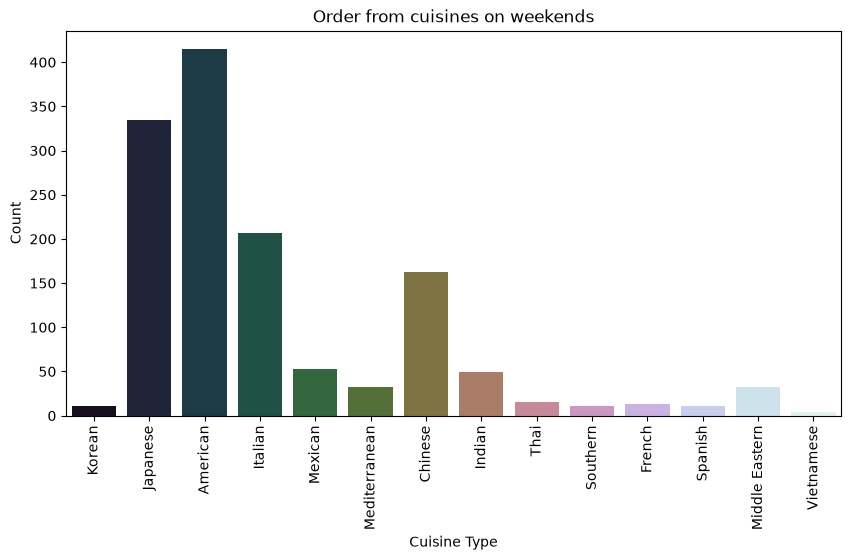

In [25]:
# Fetching the dataframe only with weekend value in the day_of _the_week column
df_weekend = df[df['day_of_the_week'] == 'Weekend' ]

#Counting cuisine type values from the fetched dataframe
df_weekend['cuisine_type'].value_counts()

# Setting up figure size of the plot
plt.figure(figsize=(10, 5))  # Set the size of the plot figure (width: 10 units, height: 5 units)

# Visualizing with seaborn
sns.countplot(data=df_weekend, x='cuisine_type', palette = 'cubehelix')  # Creating a countplot using Seaborn
plt.xlabel('Cuisine Type')  # Setting the label for the x-axis
plt.ylabel('Count')
plt.title('Order from cuisines on weekends')
plt.xticks(rotation=90)  # Rotating the x-axis labels by 90 degrees for better readability

plt.show()  # Display the plot

C:\Users\Janani\AppData\Local\Temp\ipykernel_9720\2363909393.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=df, x='cuisine_type', y='cost_of_the_order', palette='viridis')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Korean'),
  Text(1, 0, 'Japanese'),
  Text(2, 0, 'Mexican'),
  Text(3, 0, 'American'),
  Text(4, 0, 'Indian'),
  Text(5, 0, 'Italian'),
  Text(6, 0, 'Mediterranean'),
  Text(7, 0, 'Chinese'),
  Text(8, 0, 'Middle Eastern'),
  Text(9, 0, 'Thai'),
  Text(10, 0, 'Southern'),
  Text(11, 0, 'French'),
  Text(12, 0, 'Spanish'),
  Text(13, 0, 'Vietnamese')])

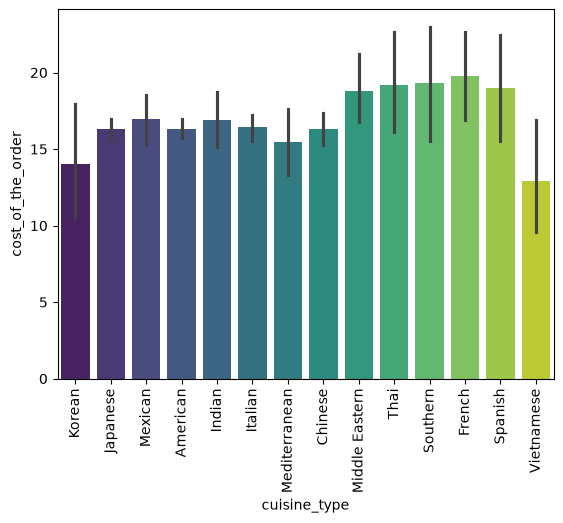

In [30]:
sns.barplot( data=df, x='cuisine_type', y='cost_of_the_order', palette='viridis')
plt.xticks(rotation=90)

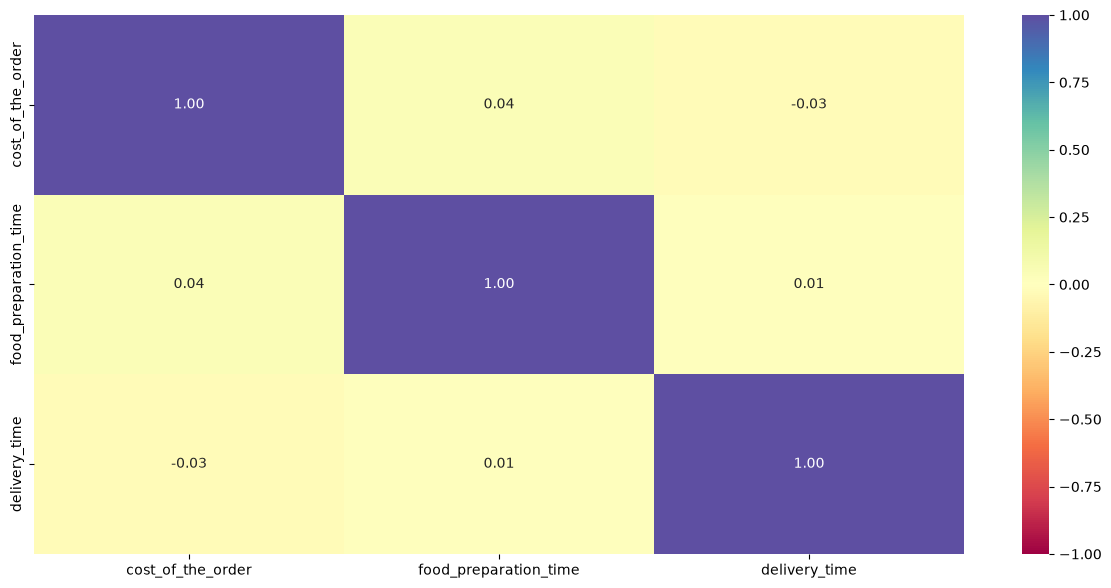

In [31]:
# plot the heatmap 
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

C:\Users\Janani\AppData\Local\Temp\ipykernel_9720\4294947680.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = df, palette = 'PuBu')


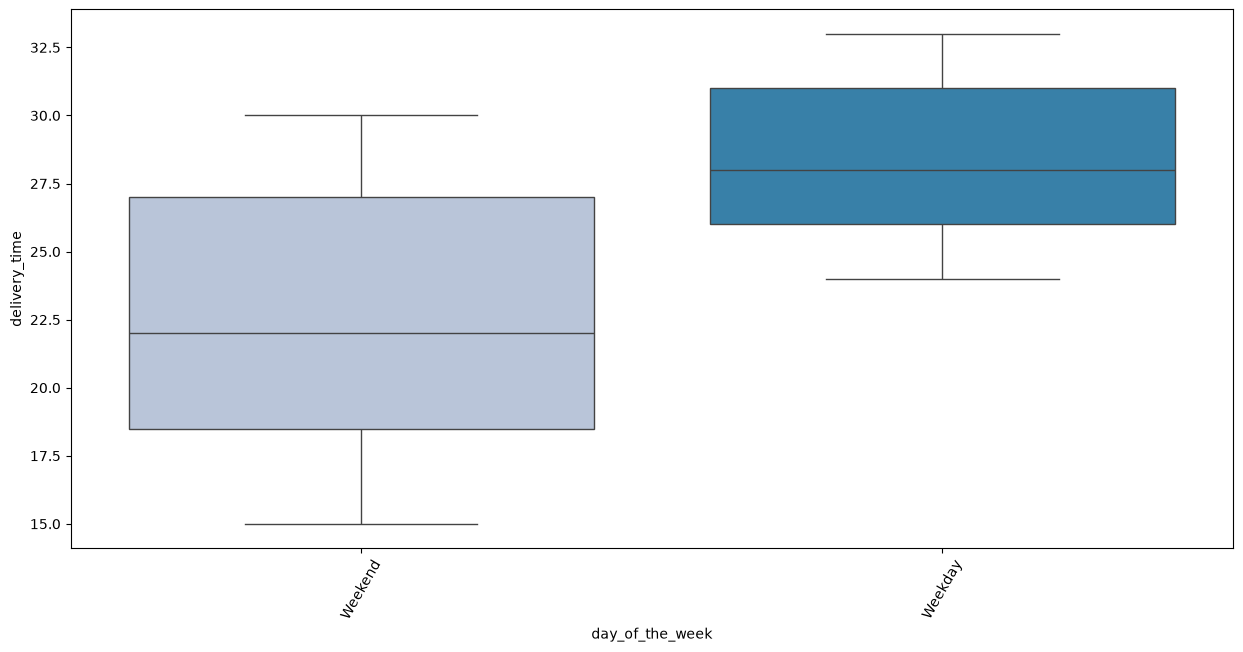

In [32]:
# Relationship between day of the week and delivery time
plt.figure(figsize=(15,7))
sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = df, palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show()

C:\Users\Janani\AppData\Local\Temp\ipykernel_9720\3198635247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu')


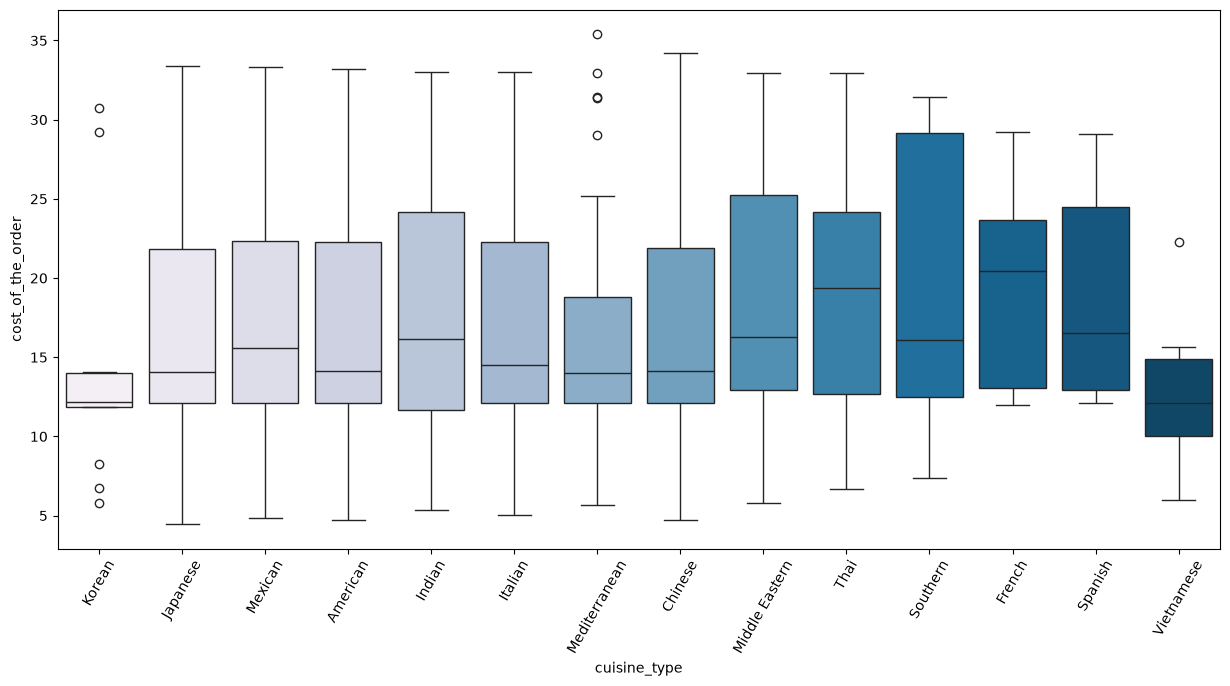

In [33]:
# Relationship between cost of the order and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show()


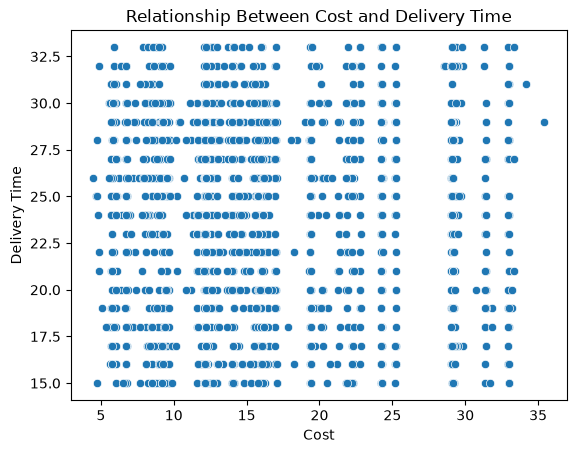

In [34]:
# for a direct visualization of the relationship between two numerical variables like cost_of_the_order and delivery_time, scatterplots are very benificial
sns.scatterplot(x='cost_of_the_order', y='delivery_time', data=df)
plt.title('Relationship Between Cost and Delivery Time')
plt.xlabel('Cost')
plt.ylabel('Delivery Time')
plt.show()

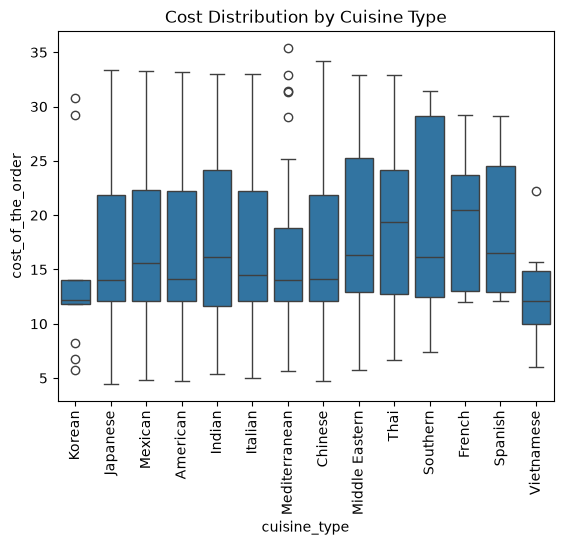

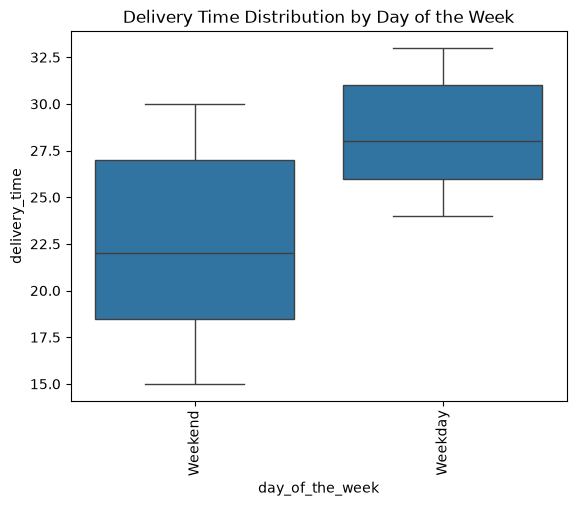

In [35]:
# box plot for cuisine type and cost
# boxplots detect trends, outliers, and differences in distributions across different categories.
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.title('Cost Distribution by Cuisine Type')
plt.xticks(rotation=90)
plt.show()
print('\n')
# Box plot for day of the week and delivery time
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title('Delivery Time Distribution by Day of the Week')
plt.xticks(rotation=90)
plt.show()

Top 5 restaurants by number of orders:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


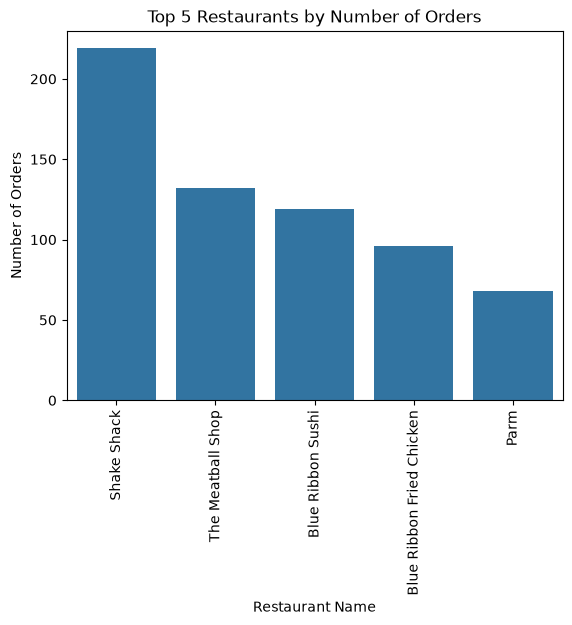

In [36]:
# Count the orders per restaurant and select the top 5
top_5_restaurants = df['restaurant_name'].value_counts().head(5)

# print top 5 restaurants
print("Top 5 restaurants by number of orders:")
print(top_5_restaurants)
# plotting the top 5 restaurants in a bar plot
sns.barplot(x=top_5_restaurants.index, y=top_5_restaurants.values)
plt.title('Top 5 Restaurants by Number of Orders')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)  # Rotating the labels for better readability
plt.show()

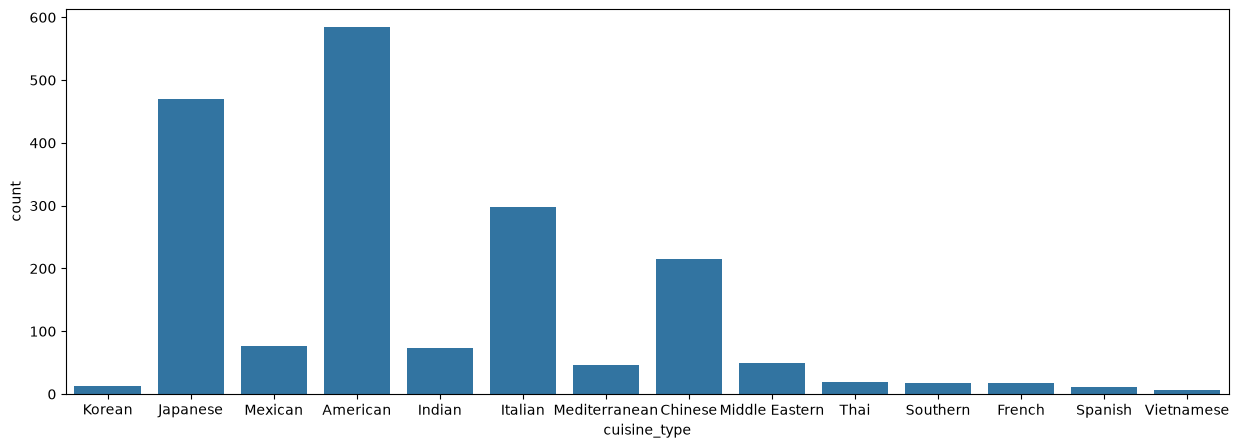

In [37]:
# check unique cuisine type
df['cuisine_type'].nunique()
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'cuisine_type');